/home/user/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


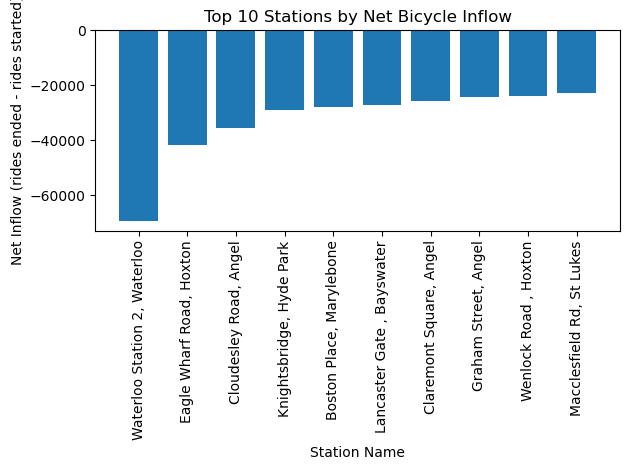

In [3]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

# Initialize BigQuery client
client = bigquery.Client()

query = """
WITH starts AS (
  SELECT b.station_name as start_station_name, COUNT(*) AS start_count
  FROM `bigdata-488403.london_bicycles_star.fact_hire` a
  LEFT JOIN `bigdata-488403.london_bicycles_star.dim_station` b
  ON a.start_station_id = b.station_id
  GROUP BY start_station_name
),
ends AS (
  SELECT d.station_name as end_station_name, COUNT(*) AS end_count
  FROM `bigdata-488403.london_bicycles_star.fact_hire` c
  LEFT JOIN `bigdata-488403.london_bicycles_star.dim_station` d
  ON c.end_station_id = d.station_id
  GROUP BY end_station_name
)
SELECT
  COALESCE(s.start_station_name, e.end_station_name) AS station_name,
  COALESCE(start_count, 0) AS rides_started,
  COALESCE(end_count, 0) AS rides_ended,
  COALESCE(end_count, 0) - COALESCE(start_count, 0) AS net_inflow
FROM starts s
FULL OUTER JOIN ends e
  ON s.start_station_name = e.end_station_name
  where COALESCE(end_count, 0) - COALESCE(start_count, 0) < 0
ORDER BY net_inflow ASC
"""

# Run query
query_job = client.query(query, location="EU")

# Convert to DataFrame
df = query_job.to_dataframe()

# Limit to top 10 stations for readability
df_top = df.head(10)

# Plot bar chart
plt.figure()
plt.bar(df_top["station_name"], df_top["net_inflow"])
#plt.bar(df_top["net_inflow"], df_top["station_name"])

plt.title("Top 10 Stations by Net Bicycle Inflow")
plt.xlabel("Station Name")
plt.ylabel("Net Inflow (rides ended - rides started)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
